In [4]:
import pandas as pd
import pickle as pkl
import os
import numpy as np
import yaml
import easydict
import json
import seaborn as sns
import matplotlib.pyplot as plt
import gseapy as gp

In [2]:
with open("../config/get_att_50.yaml", 'r') as f:
    config = easydict.EasyDict(yaml.safe_load(f))

In [23]:
with open("../data/saved_data/map/cancer_list.txt") as f:
    cancer_list = [line.rstrip('\n') for line in f]
cancer2id_map = {cancer:i for i,cancer in enumerate(cancer_list)}

In [5]:
## get gene names in gene sentence
with open("../data/saved_data/map/gene2sent_n200_notransform.pkl", 'rb') as f: 
    gene2sent_map = pkl.load(f)
with open("../data/saved_data/map/gene2id.pkl", 'rb') as f: 
    gene2id_map = pkl.load(f)

id2gene_map = {i:g for g,i in gene2id_map.items()}
id2gene_map[-1]="pad"

def get_gene_sent(g_name, cancer=8, n=60):
    g_id = gene2id_map[g_name]
    g_sent_idx = gene2sent_map[cancer][g_id]
    g_sent = [id2gene_map[g-1] for g in g_sent_idx][:n]

    return g_sent

In [6]:
def att_score(A):
    """
    Args:
    A (numpy.ndarray): Input matrix of shape (no_layers * no_heads, L, L).
    
    Returns:
    numpy.ndarray: The final attention vector of length L.
    """
    
    # Step 1: Make the matrix symmetric by adding its transpose
    if A.ndim < 3:
        A = np.expand_dims(A, axis=0)
    A_symmetric = A + A.transpose(0, 2, 1)
    
    # Step 2: Normalize the symmetric matrix
    sum_i = np.sum(A_symmetric, axis=1)  # Sum across rows
    sum_j = np.sum(A_symmetric, axis=2)  # Sum across columns
    sum_total = np.sum(A_symmetric)  # Sum of all elements
    
    # Compute the average value broadcast across elements
    avg_value = (sum_i[:, :, None] @ sum_j[:, None, :]) / sum_total  # Reshaping for broadcasting
    A_normalized = A_symmetric - avg_value  # Element-wise subtraction
    
    # Step 3: Sum along the no_layers * no_heads dimension
    A_reduced = np.sum(A_normalized, axis=0)
    
    # Step 4: Sum along the rows to generate the final attention vector
    attention_vector = np.sum(A_reduced, axis=0)
    
    return attention_vector

In [7]:
def get_gene_att_score(res_dir, data_name):
    
    with open(os.path.join(res_dir, f"{data_name}_crossatt.pkl"), 'rb') as f: 
        cross_att_all = pkl.load(f)
    with open(os.path.join(res_dir, f"{data_name}_transformeratt.pkl"), 'rb') as f: 
        trans_att_all = pkl.load(f)

    cross_att_vec = []
    for att_part in range(4):
        att_folds = []
        for fold in range(len(cross_att_all[0])):
            att = cross_att_all[att_part][fold][0,:].squeeze()
            att_folds.append(att)
        att_avg = np.mean(np.stack(att_folds), axis=0)
        cross_att_vec.append(att_score(att_avg))
    
    trans_att_vec = []
    for att_part in range(2):
        att_folds = []
        for fold in range(len(trans_att_all[0])):
            att = trans_att_all[att_part][fold][0,:].squeeze()
            att_folds.append(att)
        att_avg = np.mean(np.stack(att_folds), axis=0)
        trans_att_vec.append(att_score(att_avg))

    return cross_att_vec, trans_att_vec

#### Gene Sentence attention scores (heatmaps)

Settings

In [92]:
## 1. BRCA2-PARP1
# CANCER='BRCA'
# geneA = "BRCA2"; geneB = "PARP1"
# res_dir = f"../experiment/att/BRCA_PARP_att_50_{CANCER}"
# cancer_id = cancer2id_map[CANCER]
# gene_sent_geneB = get_gene_sent("PARP1", cancer=cancer_id, n=50)
# gene_sent_geneA = get_gene_sent("BRCA2", cancer=cancer_id, n=50)

## 2. IDH1-PRKDC
# CANCER='Glioma'
# geneA = "IDH1"; geneB = "PRKDC"
# res_dir = "../experiment/att/IDH1_PRKDC_att_50"
# cancer_id = cancer2id_map[CANCER]
# gene_sent_geneB = get_gene_sent("PRKDC", cancer=cancer_id, n=50)
# gene_sent_geneA = get_gene_sent("IDH1", cancer=cancer_id, n=50)

## 3. KRAS-TBK1
CANCER='LUAD'
geneA = "KRAS"; geneB = "TBK1"
res_dir = "../experiment/att/KRAS_TBK1_att_50_LUAD"
cancer_id = cancer2id_map[CANCER]
gene_sent_geneB = get_gene_sent("TBK1", cancer=cancer_id, n=50)
gene_sent_geneA = get_gene_sent("KRAS", cancer=cancer_id, n=50)

In [93]:
def read_att_model(res_dir, sent_len=50):

    base_dir = ".."
    cross_att_all = []
    trans_att_all = []
    model_counts = 0

    for i in range(24):
        name = f"model_no_{i}"
        with open(os.path.join(base_dir + '/' + config.task.model[name], 'params.json'), 'r') as f:
            model_params = json.load(f)
        if model_params["n"] == sent_len:
            cross_att_vec, trans_att_vec = get_gene_att_score(res_dir, name)
            cross_att_all.append(np.vstack(cross_att_vec))
            trans_att_all.append(np.vstack(trans_att_vec))
            model_counts += 1

    return cross_att_all, trans_att_all

In [94]:
## get cross att and transformer att scores
cross_att_all, trans_att_all = read_att_model(
    res_dir=res_dir,
    sent_len=50
)

print(gene_sent_geneA)
print(gene_sent_geneB)

['KRAS', 'SLC39A11', 'REXO2', 'APOL6', 'TSR3', 'MARCH6', 'ARHGDIA', 'RAB5C', 'ACOX1', 'TOMM22', 'PACSIN2', 'MAP1LC3B', 'LASP1', 'NCSTN', 'NSF', 'YWHAG', 'HSPA4', 'BAG1', 'TXNRD1', 'LPGAT1', 'FAM84B', 'AIDA', 'GNAI3', 'ARF6', 'DUSP10', 'CTDNEP1', 'PPM1A', 'HSPA9', 'ARL6IP1', 'JTB', 'MAPKAPK2', 'PRRC2B', 'CKAP4', 'PTBP3', 'SHC1', 'MED10', 'ACSL3', 'DEDD2', 'GOLPH3', 'PARP1', 'CASP7', 'DCBLD2', 'UBE2D2', 'CTNNA1', 'HTATIP2', 'CPNE3', 'pad', 'pad', 'pad', 'pad']
['TBK1', 'COLEC11', 'KCNMB4', 'SLC7A2', 'BAALC', 'TMED7', 'RET', 'DUSP10', 'KIT', 'SLC25A21', 'CHST1', 'RBM27', 'AFF4', 'GOT1', 'TMED2', 'LIF', 'NPW', 'HOXB2', 'SCIN', 'YRDC', 'GRAMD4', 'ARL5B', 'HSP90B1', 'SRPK1', 'ARHGAP5', 'SPTSSA', 'LIFR', 'PRDX3', 'NPAS3', 'ARHGAP26', 'PDCD2', 'PTGS2', 'PITPNC1', 'ARFGAP3', 'GOLM1', 'RHOU', 'PDIA2', 'PLK2', 'CBX5', 'TNFAIP3', 'SLC7A11', 'MAGT1', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad', 'pad']


Get high attention genes

In [95]:
from scipy.stats import ttest_1samp

## t-test - pick high attention genes
def att_pval(att_all, sent_len=50):

    ## convert to a np array, shape (n_models, 4, sent_len)
    att_all = np.array(att_all)
    pval_mtx = np.ones((4, sent_len))
    for group in range(4):
        overall_mean = np.mean(np.array(att_all)[:,group,:])
        for i in range(sent_len):
            att_gene = [att_all[j][group][i] for j in range(len(att_all))]
            t_stat, p_val = ttest_1samp(att_gene, overall_mean)
            if t_stat > 0:
                pval_mtx[group, i] = p_val

    return pval_mtx

def att_sig(cross_att):
    pval_mtx = att_pval(cross_att)
    pval_thr = 5e-2

    sig = pval_mtx < pval_thr

    return sig

def get_high_att_genes(cross_att):

    sig = att_sig(cross_att)
    geneA_sig = np.array([x or y for x,y in zip(sig[0], sig[3])])
    geneB_sig = np.array([x or y for x,y in zip(sig[1], sig[2])])

    geneA_sig_pos = np.array(gene_sent_geneA)[geneA_sig]
    geneA_sig_neg = np.array(gene_sent_geneA)[~geneA_sig]
    ## remove 'pad's
    geneA_sig_pos = np.array([i for i in geneA_sig_pos if i != 'pad'])
    geneA_sig_neg = np.array([i for i in geneA_sig_neg if i != 'pad'])

    geneB_sig_pos = np.array(gene_sent_geneB)[geneB_sig]
    geneB_sig_neg = np.array(gene_sent_geneB)[~geneB_sig]
    ## remove 'pad's
    geneB_sig_pos = np.array([i for i in geneB_sig_pos if i != 'pad'])
    geneB_sig_neg = np.array([i for i in geneB_sig_neg if i != 'pad'])
    
    return geneA_sig_pos, geneA_sig_neg, geneB_sig_pos, geneB_sig_neg


In [96]:
att_significance = att_sig(cross_att_all)
att_significance.shape

(4, 50)

In [97]:
import matplotlib

def plot_att_vec(vec, att_sig=None):

    if vec.shape[0] == 4:
        y_tick = ["att11", "att21", "att22", "att12"]
    elif vec.shape[0] == 2:
        y_tick = ["att1", "att2"]

    plt.rcParams.update({'font.size': 8})
    fig_width = 6 if vec.shape[0]==4 else 3
    fig, axs = plt.subplots(vec.shape[0], 1, figsize = (15, fig_width))
    fig.set_dpi(300)
    fig.tight_layout(pad=3.0)

    ## reorder
    att_order = [0,3,1,2] if vec.shape[0] == 4 else [0,1]
    for i, idx in enumerate(att_order):
        if  idx==0 or idx==3:
            x_tick = gene_sent_geneA
        elif idx==1 or idx==2:
            x_tick = gene_sent_geneB

        sns.heatmap(vec[idx,:].reshape(1,-1), ax=axs[i], square=True, cmap="OrRd", cbar=False, xticklabels=x_tick)
        norm_unsoftmax = matplotlib.colors.Normalize(vmin = np.min(vec),
                                            vmax = np.max(vec))
        cbar_unsoftmax = fig.colorbar(matplotlib.cm.ScalarMappable(norm = norm_unsoftmax, cmap="OrRd"),
                                    orientation = 'vertical', ax = axs[i])
        cbar_unsoftmax.outline.set_visible(False)

        if att_sig is not None: ## highlight the high attention genes
            labels = [
                r"$\bf{" + label + "}$" if is_bold else label
                for label, is_bold in zip(x_tick, att_sig[idx,:])
            ]
            axs[i].set_xticks(range(len(x_tick)))
            axs[i].set_xticklabels(labels, rotation=45)
        else:
            axs[i].set_xticklabels(x_tick, rotation=45)
        
        axs[i].set_ylabel(y_tick[i])

    if vec.shape[0] == 4:   
        fig.suptitle("cross attention scores")
    elif vec.shape[0] == 2:   
        fig.suptitle("transformer attention scores")

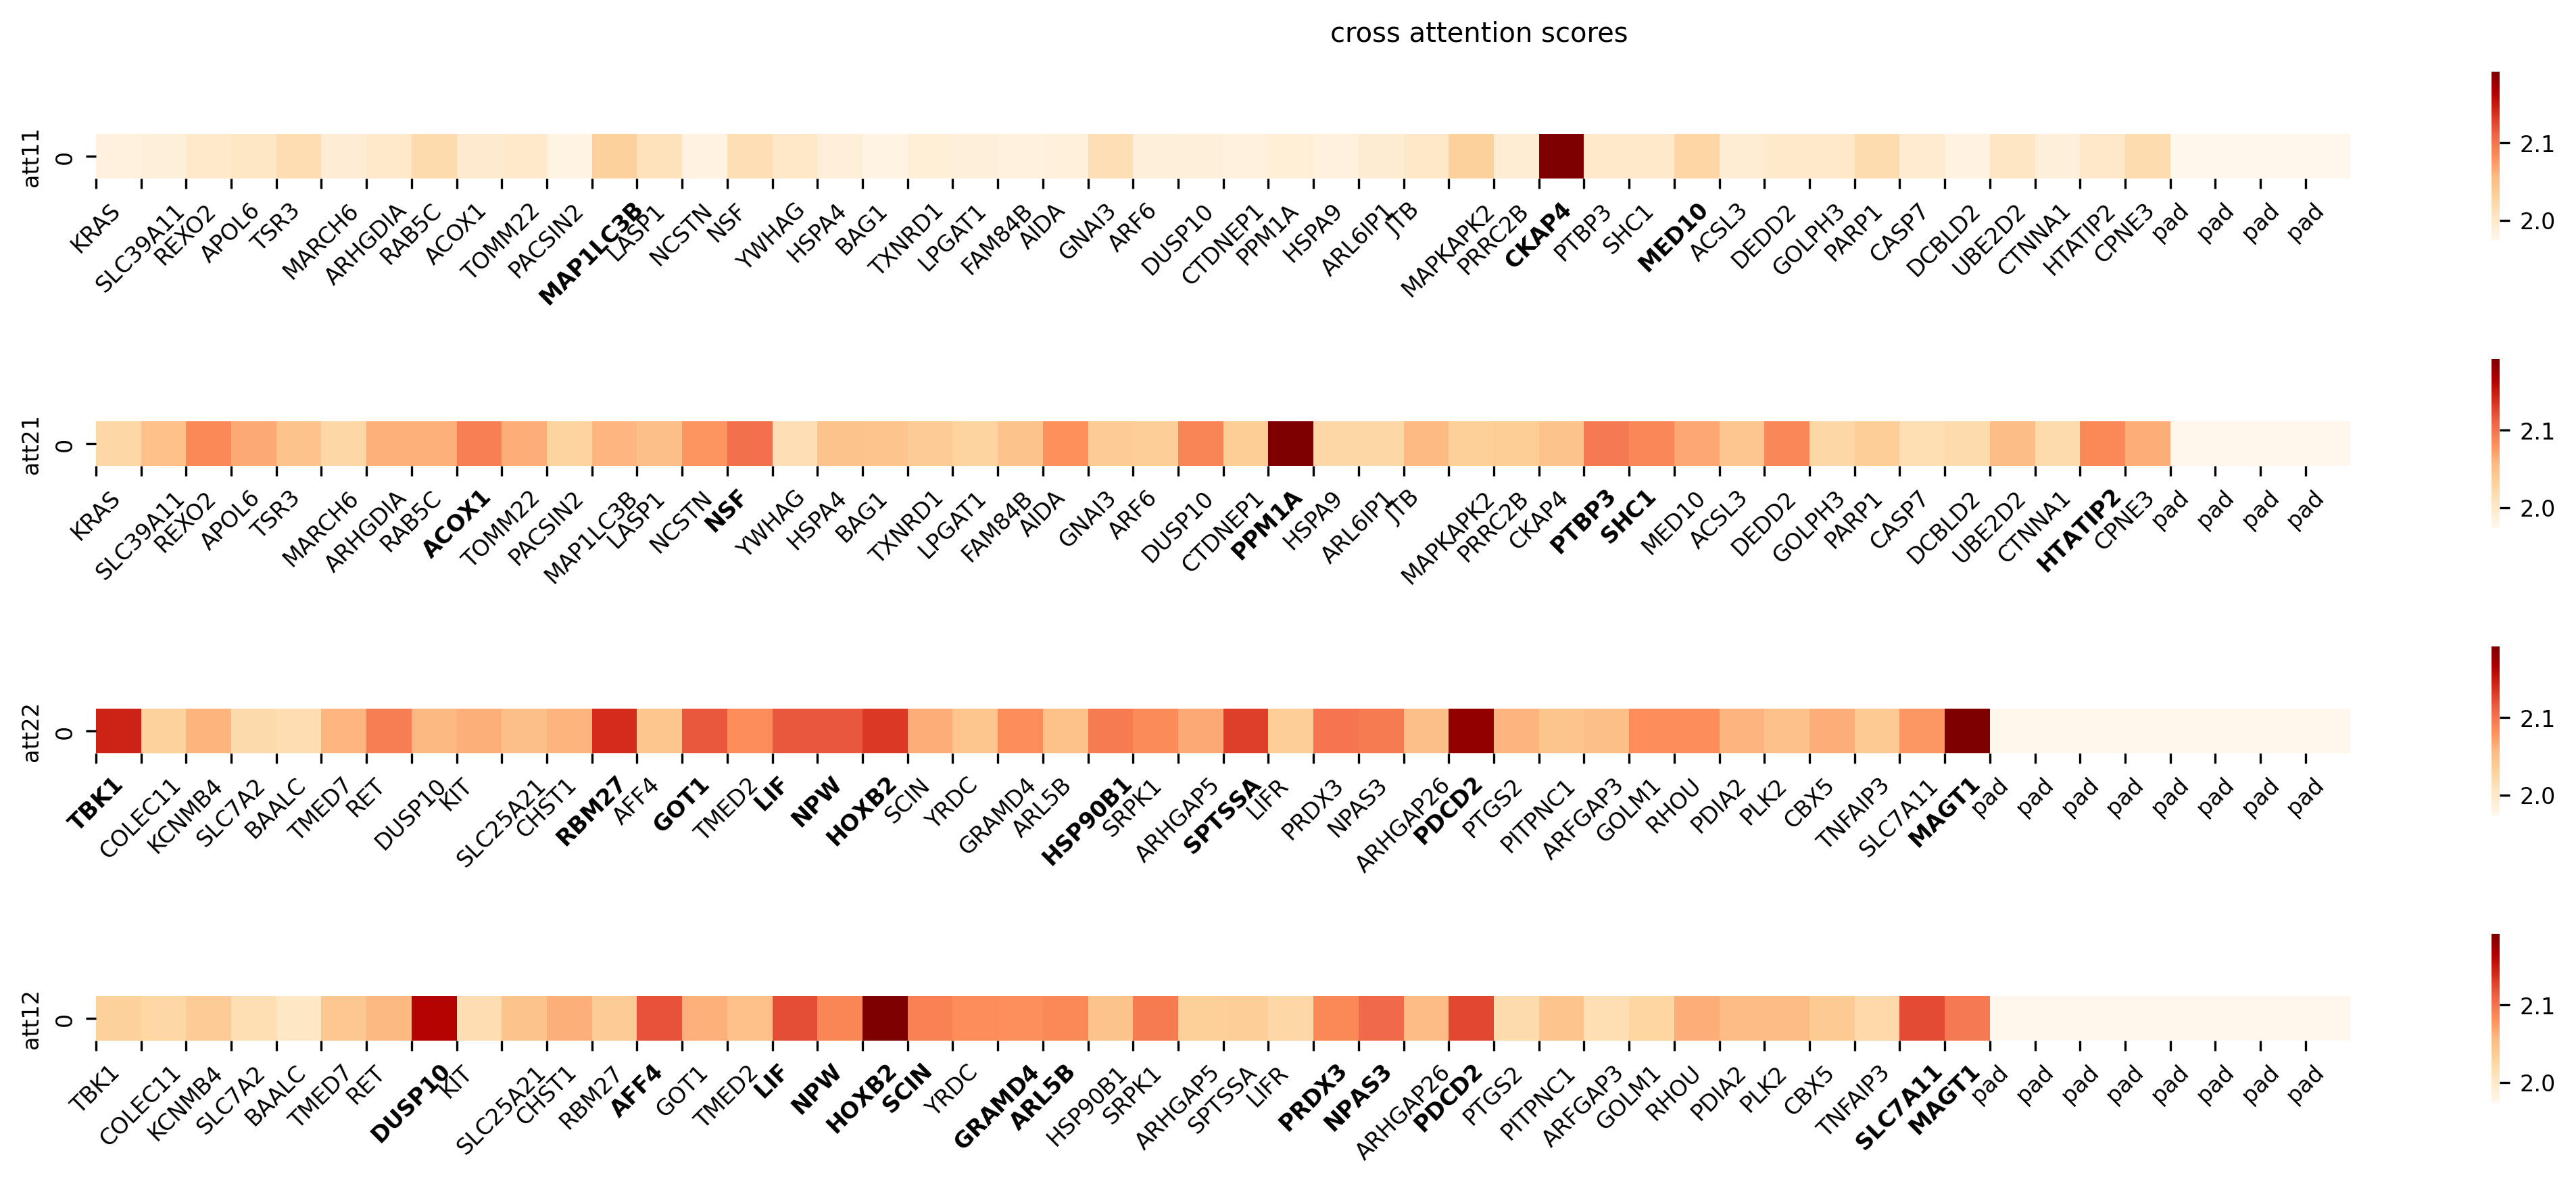

In [98]:
cross_att_avg = np.mean(np.stack(cross_att_all, axis=0), axis=0)
plot_att_vec(cross_att_avg, att_significance)

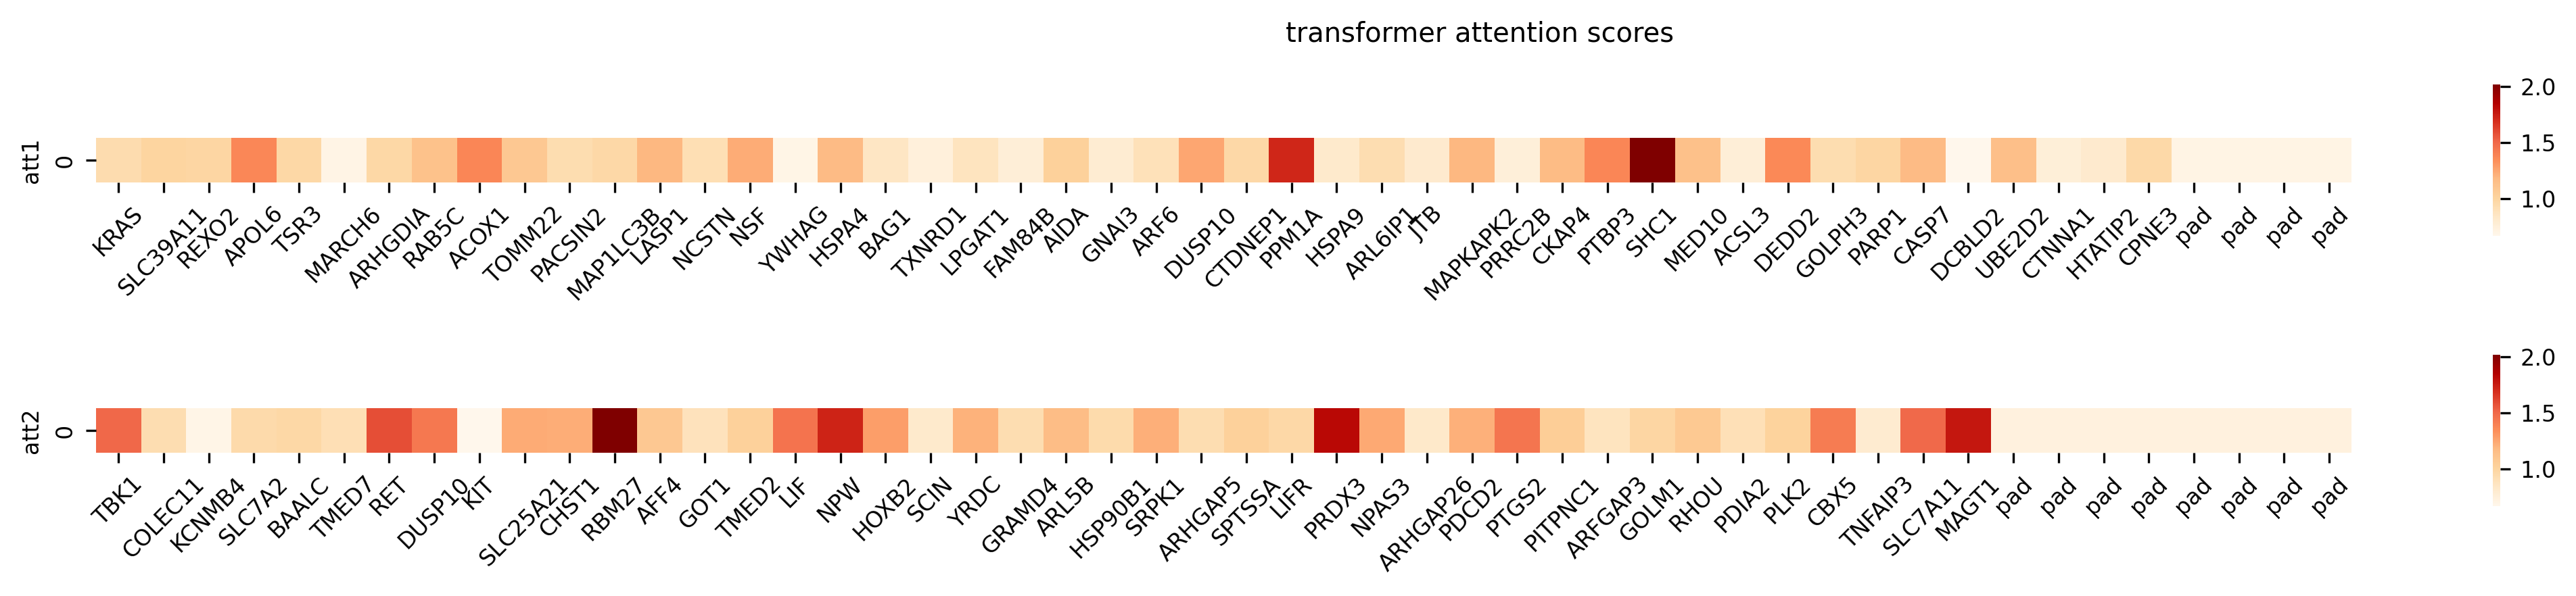

In [99]:
trans_att_avg = np.mean(np.stack(trans_att_all, axis=0), axis=0)
plot_att_vec(trans_att_avg)

#### Differential function enrichment of high attention genes

In [100]:
geneA_sig_pos, geneA_sig_neg, geneB_sig_pos, geneB_sig_neg = get_high_att_genes(cross_att_all)

Using gseapy for pathway enrichment

In [101]:
df_database = pd.DataFrame([
    ['GO_Biological_Process_2021', 6036],
    ['GO_Molecular_Function_2021', 1274],
    ['Reactome_2022', 1818],
    ['KEGG_2021_Human', 332] ####
], columns=['dataset', 'term'])

In [102]:

def enrich_diff(pos_list, neg_list):

    databases = ['Reactome_2022']
    # databases = ["KEGG_2021_Human"]
    # databases = ['GO_Biological_Process_2021', 'GO_Molecular_Function_2021']
    m = df_database[df_database['dataset'].isin(databases)]['term'].sum()
    p_thresh = 0.05 / m  # Bonferroni correction
    # p_thresh = 0.05
    print(f"Bonferroni-corrected p-value threshold: {p_thresh:.4e}")

    enr_result_pos = gp.enrichr(
        gene_list=pos_list,
        gene_sets=databases,
        organism='Human',
        # outdir=outdir,
        cutoff=0.5,  ## 0.5
    )

    result_df_pos = enr_result_pos.results
    filtered_df_pos = result_df_pos
    # filtered_df_pos = result_df_pos[result_df_pos['P-value'] < p_thresh]
    # filtered_df_pos = result_df_pos[result_df_pos['Adjusted P-value'] < 0.05]

    enr_result_neg = gp.enrichr(
        gene_list=neg_list,
        gene_sets=databases,
        organism='Human',
        # outdir=outdir,
        cutoff=0.5,  ## 0.5
    )

    result_df_neg = enr_result_neg.results
    # filtered_df_neg = result_df_neg
    filtered_df_neg = result_df_neg[result_df_neg['P-value'] < p_thresh]
    # filtered_df_neg = result_df_neg[result_df_neg['Adjusted P-value'] < 0.05]

    ## Pathways that are enriched in significant genes but not in non-significant genes
    diff_df = filtered_df_pos[~filtered_df_pos['Term'].isin(filtered_df_neg['Term'])]
    ## remove suffix
    diff_df["Term"] = diff_df["Term"].str.replace(r"\sR-HSA.*", "", regex=True)
    diff_df["Term"] = diff_df["Term"].str.replace(r"\s*\(GO:\d+\)", "", regex=True)
    filtered_df_pos["Term"] = filtered_df_pos["Term"].str.replace(r"\sR-HSA.*", "", regex=True)
    filtered_df_pos["Term"] = filtered_df_pos["Term"].str.replace(r"\s*\(GO:\d+\)", "", regex=True)
    filtered_df_neg["Term"] = filtered_df_neg["Term"].str.replace(r"\sR-HSA.*", "", regex=True)
    filtered_df_neg["Term"] = filtered_df_neg["Term"].str.replace(r"\s*\(GO:\d+\)", "", regex=True)

    return diff_df, filtered_df_pos, filtered_df_neg


In [103]:
diff_df_geneA, df_pos_geneA, df_neg_geneA = enrich_diff(list(geneA_sig_pos), list(geneA_sig_neg))
diff_df_geneB, df_pos_geneB, df_neg_geneB = enrich_diff(list(geneB_sig_pos), list(geneB_sig_neg))

Bonferroni-corrected p-value threshold: 2.7503e-05


/tmp/ipykernel_2827816/1829965325.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_neg["Term"] = filtered_df_neg["Term"].str.replace(r"\sR-HSA.*", "", regex=True)
/tmp/ipykernel_2827816/1829965325.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_neg["Term"] = filtered_df_neg["Term"].str.replace(r"\s*\(GO:\d+\)", "", regex=True)


Bonferroni-corrected p-value threshold: 2.7503e-05


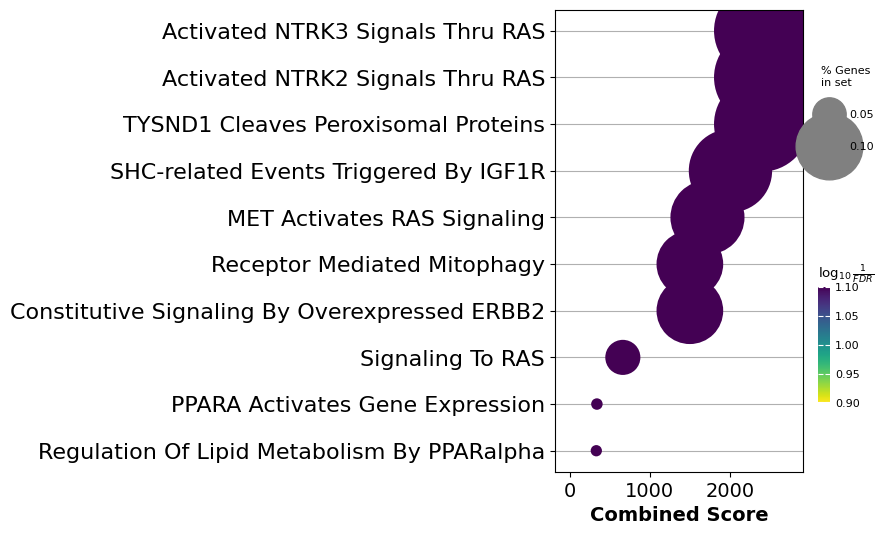

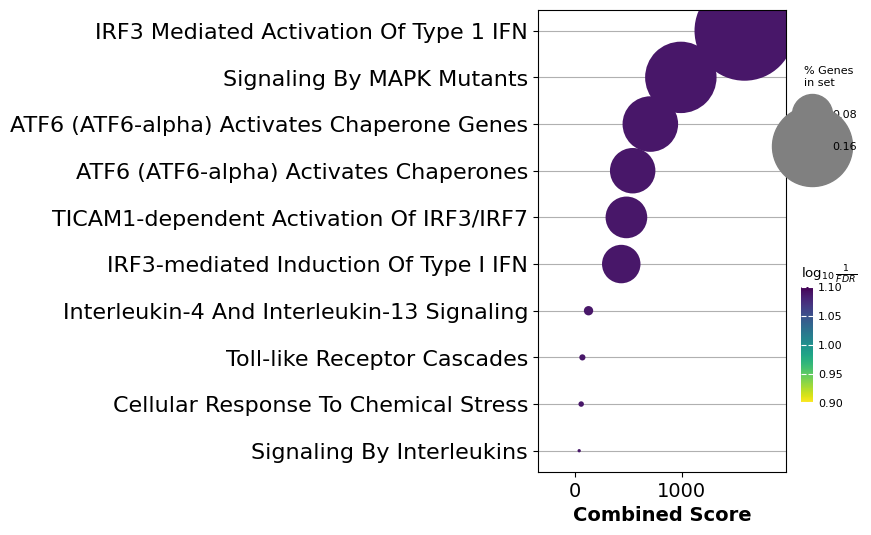

In [104]:
## plot enrichment results
## differential pathways

plt_save_dir = "../experiment/att_pval/fig"
axA = gp.dotplot(diff_df_geneA, 
           size=80,
           figsize=(4,6),
           top_term=10,
           cutoff=0.5,
           )
figA = axA.get_figure()
# figA.savefig(os.path.join(plt_save_dir,f"{geneA}_{CANCER}cancer.pdf"), dpi=300, bbox_inches='tight')

axB = gp.dotplot(diff_df_geneB, 
           size=60,
           figsize=(4,6),
           top_term=10,
           cutoff=0.5,
           )
figB = axB.get_figure()
# figB.savefig(os.path.join(plt_save_dir,f"{geneB}_{CANCER}cancer.pdf"), dpi=300, bbox_inches='tight')


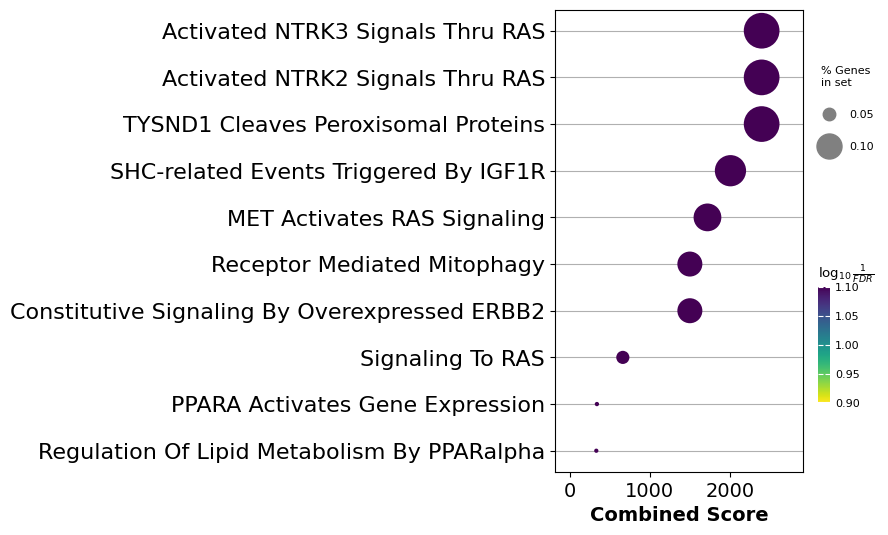

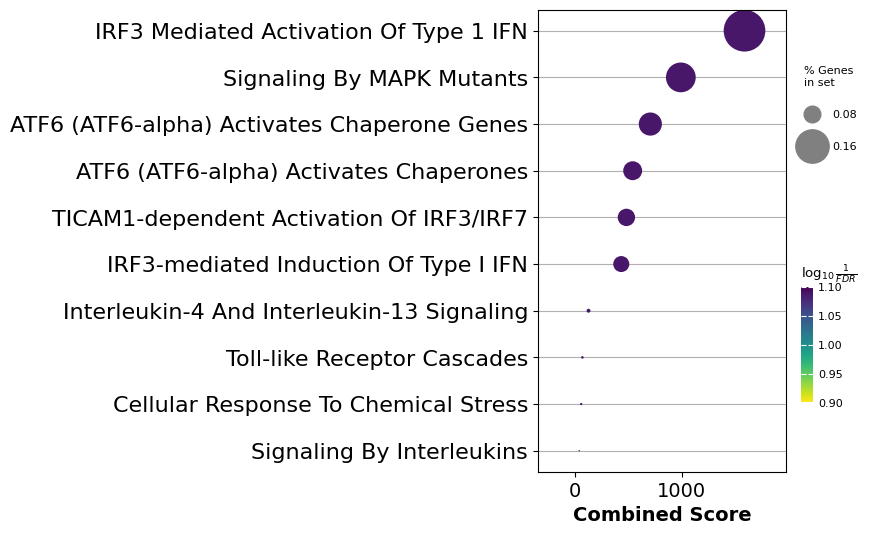

In [108]:
## high attention genes enrichment

plt_save_dir = "../experiment/att_pval/fig"
axA = gp.dotplot(df_pos_geneA, 
           size=30,
           figsize=(4,6),
           top_term=10,
           cutoff=0.5,
           )
figA = axA.get_figure()
figA.savefig(os.path.join(plt_save_dir,f"{geneA}_{CANCER}cancer_pos.pdf"), dpi=300, bbox_inches='tight')

axB = gp.dotplot(df_pos_geneB, 
           size=25,
           figsize=(4,6),
           top_term=10,
           cutoff=0.5,
           )
figB = axB.get_figure()
figB.savefig(os.path.join(plt_save_dir,f"{geneB}_{CANCER}cancer_pos.pdf"), dpi=300, bbox_inches='tight')


ValueError: Warning: No enrich terms when cutoff = 0.5

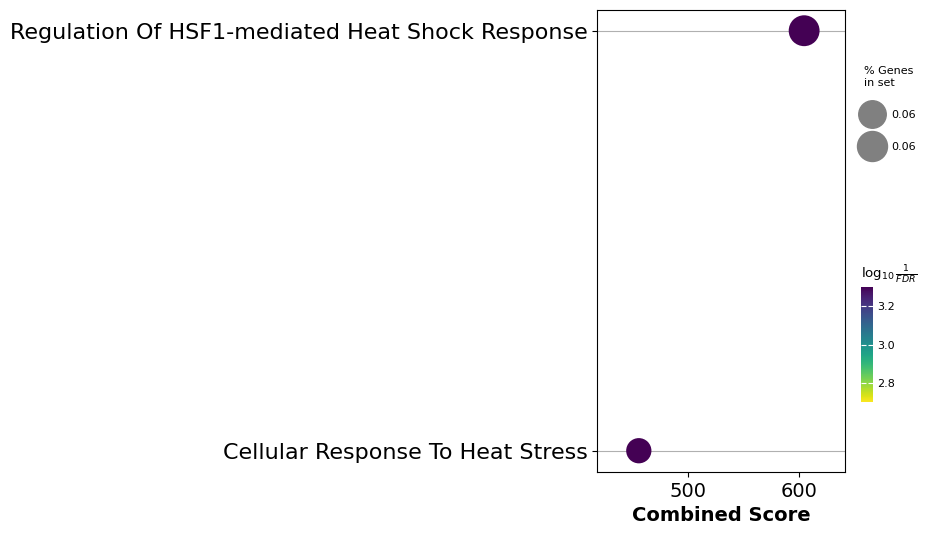

In [111]:
## low attention genes enrichment

plt_save_dir = "../experiment/att_pval/fig"
axA = gp.dotplot(df_neg_geneA, 
           size=60,
           figsize=(4,6),
           top_term=10,
           cutoff=0.5,
           )
figA = axA.get_figure()
figA.savefig(os.path.join(plt_save_dir,f"{geneA}_{CANCER}cancer_neg.pdf"), dpi=300, bbox_inches='tight')

axB = gp.dotplot(df_neg_geneB, 
           size=60,
           figsize=(4,6),
           top_term=10,
           cutoff=0.5,
           )
figB = axB.get_figure()
figB.savefig(os.path.join(plt_save_dir,f"{geneB}_{CANCER}cancer_neg.pdf"), dpi=300, bbox_inches='tight')
